## What counts as a real light echo (written before looking at the data)
A feature is a real echo only if ALL of these are true:
1. It appears on several different nights in the same season.
2. It appears in both the g and r filters.
3. It does NOT appear in the 2018–2020 (pre-eruption) images processed the same way.
4. It moves outward from the nova from one season to the next.
Anything that fails a check is called a "candidate", not an echo.


In [1]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.6 MB/s eta 0:00:00


In [2]:
from astroquery.mast import Observations
from astropy.time import Time

obs = Observations.query_criteria(objectname="V838 Mon", radius="0.02 deg",
                                  obs_collection="HST", instrument_name="ACS/WFC",
                                  dataproduct_type="image")
obs["date"] = Time(obs["t_min"], format="mjd").iso
print(len(obs), "observations found")

206 observations found


In [3]:
obs.sort("t_min")
obs["obs_id", "date", "filters", "t_exptime"].pprint(max_lines=60)

                      obs_id                       ...  t_exptime  
-------------------------------------------------- ... ------------
  hst_skycell-p1169x07y20_acs_wfc_f435w-pol0uv_all ...       1012.0
           hst_9587_01_acs_wfc_f435w-pol0uv_j8gg01 ...        506.0
  hst_skycell-p1259x19y03_acs_wfc_f435w-pol0uv_all ...       1012.0
                  hst_9587_01_acs_wfc_total_j8gg01 ...       1518.0
                                         j8gg01010 ...        506.0
 hst_skycell-p1169x07y20_acs_wfc_f435w-pol60uv_all ...       1012.0
          hst_9587_01_acs_wfc_f435w-pol60uv_j8gg01 ...        506.0
 hst_skycell-p1259x19y03_acs_wfc_f435w-pol60uv_all ...       1012.0
                                         j8gg01020 ...        506.0
                                         j8gg01030 ...        506.0
hst_skycell-p1259x19y03_acs_wfc_f435w-pol120uv_all ...       1012.0
         hst_9587_01_acs_wfc_f435w-pol120uv_j8gg01 ...        506.0
hst_skycell-p1169x07y20_acs_wfc_f435w-pol120uv_a

In [4]:
import numpy as np

keep = np.array([o.startswith("j") and "POL" not in f.upper()
                 for o, f in zip(obs["obs_id"], obs["filters"])])
good = obs[keep]
good["day"] = [d[:10] for d in good["date"]]
good["obs_id", "day", "filters", "t_exptime"].pprint_all()

  obs_id     day     filters t_exptime
--------- ---------- ------- ---------
j8gg01010 2002-04-30   F435W     506.0
j8gg01020 2002-04-30   F435W     506.0
j8gg01030 2002-04-30   F435W     506.0
j8gl03010 2002-05-20   F606W     362.0
j8gl03020 2002-05-20   F606W     362.0
j8gl03030 2002-05-20   F606W     362.0
j8gl03ilq 2002-05-20   F814W      30.0
j8gg02010 2002-05-20   F435W     506.0
j8gg02020 2002-05-20   F435W     506.0
j8gg02030 2002-05-21   F435W     506.0
j8jy04010 2002-09-02   F606W     960.0
j8jy04020 2002-09-02   F606W     960.0
j8jy04030 2002-09-02   F606W     960.0
j8jy04040 2002-09-02   F435W    1160.0
j8jy04060 2002-09-02   F814W     200.0
j8jy04050 2002-09-02   F435W    1720.0
j8jy05040 2002-10-28   F814W     360.0
j8jy05010 2002-10-28   F435W    2120.0
j8jy05020 2002-10-28   F435W    1700.0
j8jy05050 2002-10-28   F606W     700.0
j8jy05030 2002-10-28   F435W    2060.0
j8jy06010 2002-12-17   F606W     910.0
j8jy06020 2002-12-17   F606W     910.0
j8jy06030 2002-12-17   F6

In [5]:
pick = good[(good["obs_id"] == "j8jy04050") | (good["obs_id"] == "j8jy06050")]
products = Observations.get_product_list(pick)
drz = Observations.filter_products(products, productSubGroupDescription="DRZ",
                                   extension="fits")
files = Observations.download_products(drz)
print(files["Local Path", "Status"])

                   Local Path                    Status 
----------------------------------------------- --------
./mastDownload/HST/j8jy06050/j8jy06051_drz.fits COMPLETE
./mastDownload/HST/j8jy04050/j8jy04051_drz.fits COMPLETE


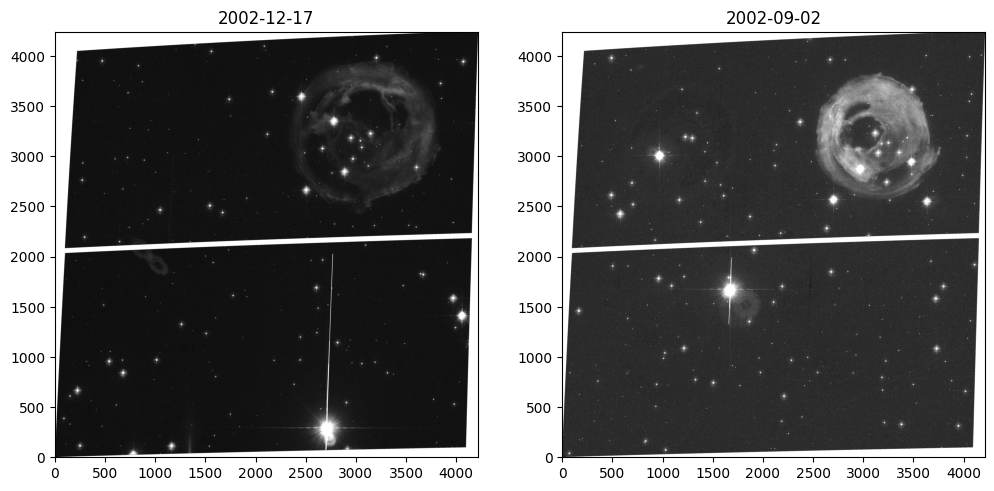

In [6]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, path in zip(axes, files["Local Path"]):
    data = fits.getdata(path, ext=1)
    ax.imshow(data, origin="lower", cmap="gray",
              norm=simple_norm(data, stretch="asinh", percent=99.5))
    ax.set_title(fits.getheader(path)["DATE-OBS"])
plt.show()

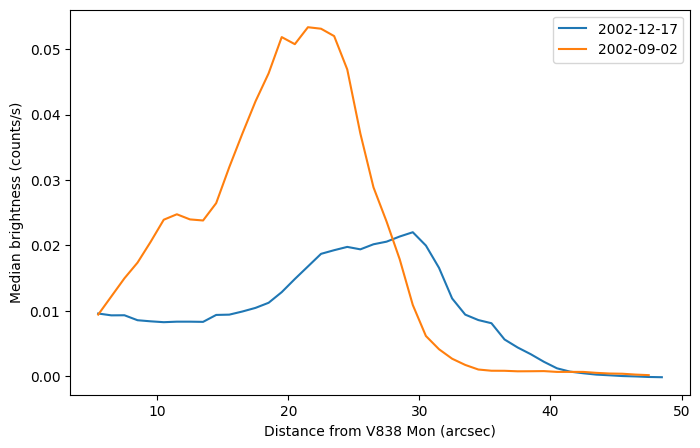

In [7]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

star = SkyCoord.from_name("V838 Mon")
bins = np.arange(5, 80, 1.0)                     # rings from 5" to 80" from the star

plt.figure(figsize=(8, 5))
for path in files["Local Path"]:
    data = fits.getdata(path, ext=1)
    w = WCS(fits.getheader(path, ext=1))
    date = fits.getheader(path)["DATE-OBS"]
    x0, y0 = w.world_to_pixel(star)              # where the star is in this image
    yy, xx = np.indices(data.shape)
    r = np.hypot(xx - x0, yy - y0) * 0.05        # distance from the star, in arcsec
    ok = data != 0                               # skip the empty edges and chip gap
    prof = [np.median(data[ok & (r >= b) & (r < b + 1)]) for b in bins]
    plt.plot(bins + 0.5, prof, label=date)

plt.xlabel("Distance from V838 Mon (arcsec)")
plt.ylabel("Median brightness (counts/s)")
plt.legend()
plt.show()

In [8]:
d_ly = 6100 * 3.2616          # distance to V838 Mon: 6.1 kpc, in light-years
flash = Time("2002-02-06")    # main outburst peak

for date, edge in [("2002-09-02", 27.0), ("2002-12-17", 32.9)]:
    t = (Time(date) - flash).to("yr").value     # years since the flash (= c*t in light-years)
    x = d_ly * edge / 206265                    # edge distance across the sky, in light-years
    z = x**2 / (2 * t) - t / 2                  # paraboloid: how far in front of the star
    print(f"{date}: t = {t:.2f} yr, x = {x:.2f} ly, dust is {z:.1f} ly in front of the star")

2002-09-02: t = 0.57 yr, x = 2.60 ly, dust is 5.7 ly in front of the star
2002-12-17: t = 0.86 yr, x = 3.17 ly, dust is 5.4 ly in front of the star
